# 02 - Mentions over time (per ticker)

**What this does:** reads the cleaned slice saved by **notebook 01**
(`data/processed/posts_slice.parquet`) — so it automatically uses the SAME
time window and subreddits you set there — finds the stock tickers in each
post, and counts mentions per day, **per source** (Reddit vs X) and
**combined**. It makes **two graphs** on the combined signal:

1. **Raw mentions** - every post counts as 1.
2. **Upvote-weighted mentions** - each mention is weighted by the post's upvotes
   (score). This leans on what the crowd actually pushed up, so a few high-upvote
   posts matter more than lots of ignored ones. _X rows carry score 0 (the
   dataset has no like counts), so the weighted signal is effectively
   Reddit-only - cross-source comparisons use RAW counts._

It saves TWO files: `daily_ticker_counts.parquet` (combined - notebook 03 and
everything downstream use this) and `daily_ticker_counts_by_source.parquet`
(per-source - powers the Reddit-vs-X comparison at the bottom). The chain is:
**01 (slice + screening) → 02 (counts) → 03 (take-offs)** — to change the
window or subreddits, edit notebook 01 and re-run the chain from there.

_Note:_ the first run downloads the official Nasdaq ticker list (needs internet)
and caches it under `data/reference/`.

**Ticker matching rules** (`src/extract_tickers.py`): a mention is either a
cashtag (`$GME`, any case) or a bare **ALL-CAPS** 4-5 letter word (`NVDA`)
that is in the official US ticker universe and not on the stop lists.
Lowercase words never count - "i took out a loan" is not a $LOAN mention.
On top of that, **word-tickers** (LOAN, EDGE, RENT, TECH, ... — classified by
notebook 01's screening section using case ratio + wordfreq) only count when
written as cashtags: bare `LOAN` is ignored, `$LOAN` still counts.

In [1]:
import os, sys
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
print('project root:', ROOT)

project root: c:\Users\alexd\Desktop\GIC\RetailFlow1


In [2]:
# ============ PARAMETERS - edit these ============
# NOTE: no TIME WINDOW here any more. The window and subreddits come from
# notebook 01, via the slice file it saves - one source of truth for the chain.
SLICE_PATH        = os.path.join(ROOT, 'data', 'processed', 'posts_slice.parquet')
CASHTAGS_ONLY     = False   # True = only count $TICKER (cleaner, fewer false hits)
TICKERS_TO_PLOT   = []      # e.g. ['GME', 'AMC']; [] = use the TOP_N most mentioned
TOP_N             = 6
DAILY_COUNTS_OUT  = os.path.join(ROOT, 'data', 'processed', 'daily_ticker_counts.parquet')
BY_SOURCE_OUT     = os.path.join(ROOT, 'data', 'processed', 'daily_ticker_counts_by_source.parquet')
# ==================================================

In [3]:
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path

# Force-reload src modules so a kernel that imported them BEFORE notebook 01
# (re)built ticker_classification.csv picks up the fresh screening list.
# Python caches imports per kernel - editing files on disk doesn't refresh
# them, and the screening CSV is read once at import time.
import importlib
import src.extract_tickers, src.build_mentions
importlib.reload(src.extract_tickers)
importlib.reload(src.build_mentions)
from src.extract_tickers import SCREENED_STOP
from src.build_mentions import build_daily_counts
from src.ticker_universe import load_us_ticker_universe

# The cleaned slice saved by notebook 01 - THIS is how 02 inherits 01's
# TIME WINDOW and SUBREDDITS. No filters are re-declared here.
if not os.path.exists(SLICE_PATH):
    raise FileNotFoundError(
        'posts_slice.parquet not found - run notebook 01 first '
        '(it saves the cleaned slice this notebook reads).')

cols = ['date', 'title', 'selftext', 'score']
if 'source' in pq.ParquetFile(SLICE_PATH).schema_arrow.names:
    cols.append('source')
posts = pd.read_parquet(SLICE_PATH, columns=cols)
if 'source' not in posts.columns:
    posts['source'] = 'reddit'   # X data not merged yet - see add_x_data.py
print('posts:', f'{len(posts):,}', '| window:', posts['date'].min(), '->', posts['date'].max())
print('by source:', posts['source'].value_counts().to_dict())

# Word-ticker screening status (built by notebook 01's last section).
if SCREENED_STOP:
    print(len(SCREENED_STOP), 'word-tickers demoted to cashtag-only (LOAN, EDGE, RENT, ...)')
else:
    print('WARNING: ticker_classification.csv not found - word-tickers like')
    print('LOAN/EDGE will pollute the counts. Run notebook 01, last section.')

# Valid US tickers (cached; re-downloaded at most once a year -
# delete the cached .txt files under data/reference/ to force a refresh).
universe = load_us_ticker_universe(Path(ROOT) / 'data' / 'reference', max_cache_age_days=365)
print('ticker universe size:', len(universe))

# Count mentions PER SOURCE first, then sum into the combined signal.
# 'by_source' powers the Reddit-vs-X comparison at the bottom of this
# notebook; 'daily' (combined) is what every other cell and notebook 03 use.
parts = []
for src_name in sorted(posts['source'].unique()):
    d = build_daily_counts(posts[posts['source'] == src_name], universe,
                           cashtags_only=CASHTAGS_ONLY)
    d['source'] = src_name
    parts.append(d)
by_source = pd.concat(parts, ignore_index=True)
by_source.to_parquet(BY_SOURCE_OUT, index=False)

daily = (by_source.groupby(['date', 'ticker'], as_index=False)
         [['mention_count', 'weighted_count']].sum())
daily.to_parquet(DAILY_COUNTS_OUT, index=False)
print('combined daily rows:', len(daily), '-> saved', DAILY_COUNTS_OUT)
print('per-source rows    :', len(by_source), '-> saved', BY_SOURCE_OUT)
daily.head()

posts: 2,833,008 | window: 2021-01-01 -> 2021-12-31
by source: {'reddit': 2832937, 'x': 71}
417 word-tickers demoted to cashtag-only (LOAN, EDGE, RENT, ...)
ticker universe size: 12381
combined daily rows: 79543 -> saved c:\Users\alexd\Desktop\GIC\RetailFlow1\data\processed\daily_ticker_counts.parquet
per-source rows    : 79554 -> saved c:\Users\alexd\Desktop\GIC\RetailFlow1\data\processed\daily_ticker_counts_by_source.parquet


,date,ticker,mention_count,weighted_count
0,2021-01-01,AAPL,8,5105
1,2021-01-01,ABBV,1,4
2,2021-01-01,ABNB,1,49
3,2021-01-01,ADSK,1,2401
4,2021-01-01,AGG,1,1


In [4]:
import matplotlib.pyplot as plt
daily['date'] = pd.to_datetime(daily['date'])

# Decide which tickers to draw (same set for both graphs).
if TICKERS_TO_PLOT:
    chosen = TICKERS_TO_PLOT
else:
    totals = daily.groupby('ticker')['mention_count'].sum().sort_values(ascending=False)
    chosen = list(totals.head(TOP_N).index)
print('plotting:', chosen)

def plot_signal(column, title, ylabel):
    plt.figure(figsize=(12, 6))
    for ticker in chosen:
        one = daily[daily['ticker'] == ticker].sort_values('date')
        plt.plot(one['date'], one[column], marker='o', markersize=3, label=ticker)
    plt.title(title)
    plt.xlabel('date'); plt.ylabel(ylabel)
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()

plotting: ['GME', 'AMC', 'SNDL', 'PLTR', 'TSLA', 'BB']


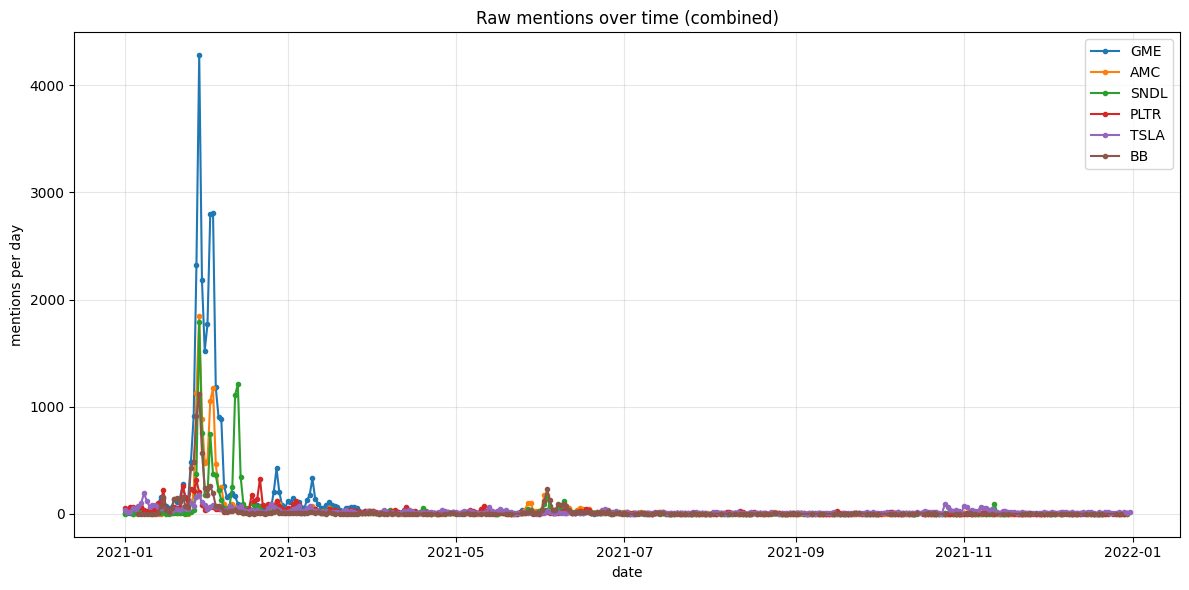

In [5]:
# GRAPH 1 - raw mentions, combined reddit+x (every post counts as 1)
plot_signal('mention_count', 'Raw mentions over time (combined)', 'mentions per day')

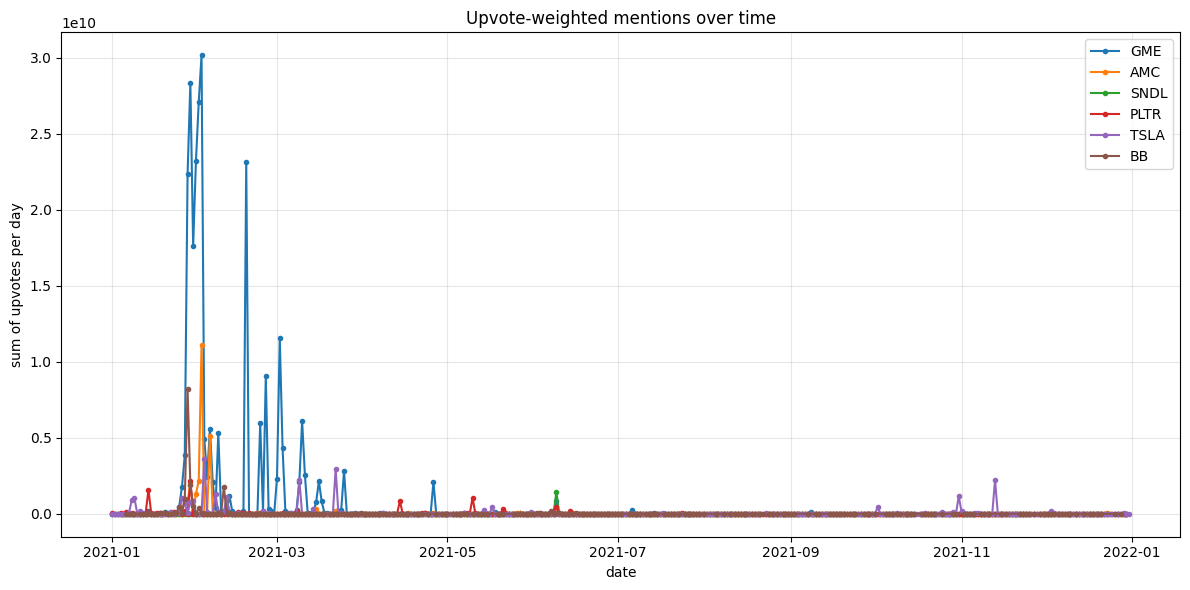

In [6]:
# GRAPH 2 - upvote-weighted mentions (X rows have score 0, so this is
# effectively the Reddit-only crowd-endorsement signal)
plot_signal('weighted_count', 'Upvote-weighted mentions over time', 'sum of upvotes per day')

## Raw mention counts - the actual numbers

Tables of the counts behind the plots: all-time totals per ticker, and each
year's top 10 with the year's total. Useful for sanity-checking (and for
spotting false-positive 'tickers' that are really just all-caps words - most
are auto-demoted by notebook 01's screening now; add stubborn ones to
`BARE_PROSE_STOP` in `src/extract_tickers.py`).

In [7]:
# All-time totals per ticker (top 20 by raw mention count).
alltime = (
    daily.groupby('ticker')
    .agg(total_mentions=('mention_count', 'sum'),
         days_active=('date', 'nunique'),
         busiest_day=('mention_count', 'max'))
    .sort_values('total_mentions', ascending=False)
)
alltime.head(20)

,total_mentions,days_active,busiest_day
ticker,,,
GME,30769,336,4281
AMC,12769,326,1848
SNDL,12251,314,1795
PLTR,8588,354,328
TSLA,8199,363,191
BB,7771,269,1116
CLOV,7716,309,805
NOK,5049,174,1143
SPCE,4112,290,323


In [8]:
# Top 10 tickers per year, with the raw counts.
daily['year'] = daily['date'].dt.year
per_year = daily.groupby(['year', 'ticker'])['mention_count'].sum().reset_index()
top10 = (
    per_year.sort_values(['year', 'mention_count'], ascending=[True, False])
    .groupby('year')
    .head(10)
    .rename(columns={'mention_count': 'total_mentions'})
)
# One row per year, tickers listed with their counts - easy to scan.
for year, grp in top10.groupby('year'):
    row = ', '.join(f"{t} ({c:,})" for t, c in zip(grp['ticker'], grp['total_mentions']))
    print(f'{year}: {row}')

2021: GME (30,769), AMC (12,769), SNDL (12,251), PLTR (8,588), TSLA (8,199), BB (7,771), CLOV (7,716), NOK (5,049), SPCE (4,112), AAPL (4,033)


## Per-year view

One plot **per year**, and each year picks its **own** top tickers.

Why: upvote scores in the archive are *mature* (a 2021 viral post shows its
full 100k upvotes), so on an all-time chart old years dominate both the
ticker choice and the y-axis. Splitting by year means every year competes
only with itself.

In [9]:
# PER-YEAR GRAPHS - each year picks its own top tickers.
YEARLY_TOP_N = 6   # tickers per year

daily['year'] = daily['date'].dt.year

def plot_year(column, ylabel):
    for year in sorted(daily['year'].unique()):
        one_year = daily[daily['year'] == year]
        # This year's OWN ranking (by the same column we're plotting).
        totals = one_year.groupby('ticker')[column].sum().sort_values(ascending=False)
        top = list(totals.head(YEARLY_TOP_N).index)
        if not top:
            continue
        plt.figure(figsize=(12, 5))
        for ticker in top:
            one = one_year[one_year['ticker'] == ticker].sort_values('date')
            plt.plot(one['date'], one[column], marker='o', markersize=2, label=ticker)
        plt.title(f'{year} - top {len(top)} tickers by {column}')
        plt.xlabel('date'); plt.ylabel(ylabel)
        plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
        plt.show()

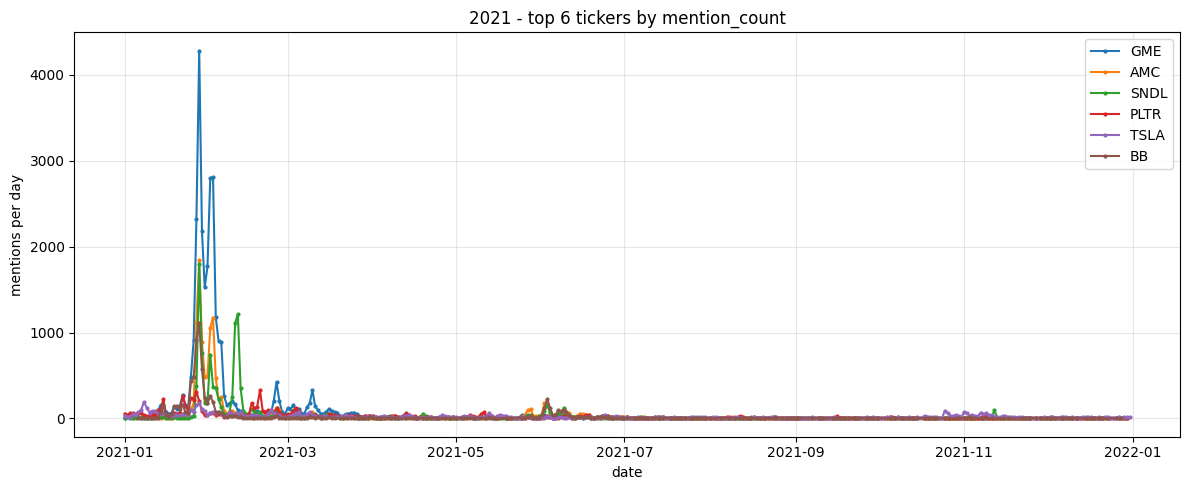

In [10]:
# Per-year GRAPH 1 - raw mentions (every post counts as 1)
plot_year('mention_count', 'mentions per day')

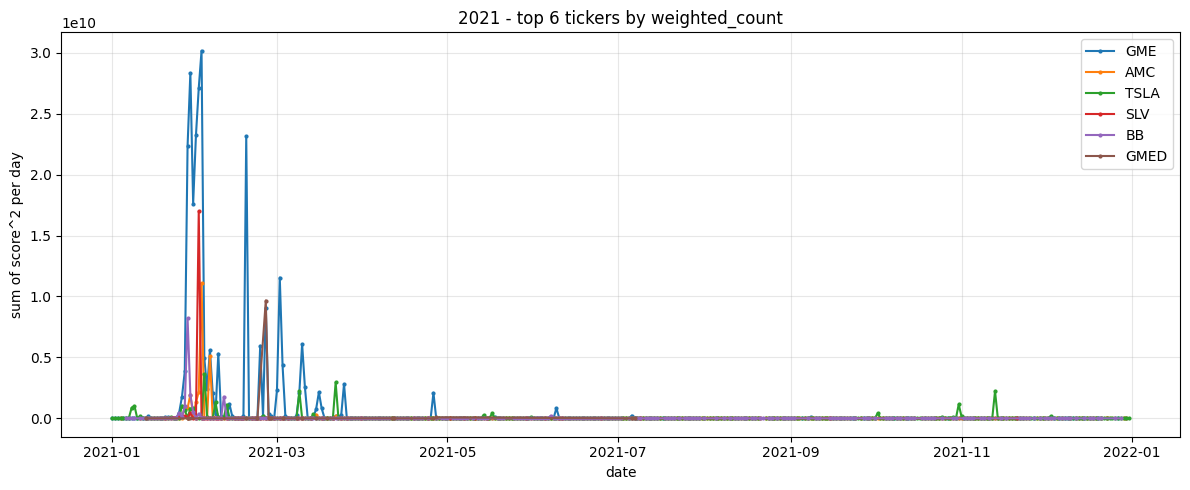

In [11]:
# Per-year GRAPH 2 - upvote-weighted mentions
plot_year('weighted_count', 'sum of score^2 per day')

## Weekly rolling view + z-scores (combined signal)

Daily counts are jagged (weekday/weekend cycle, small integers). Three
progressively smoother views, all computed on the COMBINED reddit+x signal:

1. **7-day rolling total** - every day shows the past week's mentions, which
   erases the weekend dip entirely.
2. **Rolling z-score (time-series)** - "how unusual is this week vs the SAME
   ticker's own recent baseline?" `z = (this week - 12-week average) / 12-week
   std`. A z of +3 means ~3 standard deviations above its own normal - a
   genuine attention spike, whether the ticker usually gets 5 or 5,000
   mentions. This makes big and small tickers directly comparable.
3. **Cross-sectional z-score** - "how unusual is this ticker vs ALL OTHER
   tickers this week?" Computed on log(1+mentions) across every ticker each
   day. High cross-sectional z = the ticker dominates the conversation right
   now; rising cross-sectional z = it's climbing the leaderboard. Use the
   rolling z to time a ticker's own take-off, the cross-sectional z to rank
   tickers against each other.

**Warm-up caveat:** the rolling z needs `Z_MIN_DAYS` (28) of history before it
produces a value, so the first month of your window has NO z-score. If the
event you care about is near the start of the window (e.g. the January 2021
GME squeeze), move `START_DATE` back ~3 months **in notebook 01** so the
baseline exists before the event.

In [12]:
# ============ ROLLING / Z-SCORE parameters ============
ROLL_DAYS   = 7      # rolling window for the weekly view (days)
Z_BASELINE  = 84     # rolling z baseline: 84 days = 12 weeks
Z_MIN_DAYS  = 28     # need at least this much history before z is computed
# =======================================================
import numpy as np

# Build a complete day x ticker matrix (missing days = 0) - the foundation
# for every rolling calculation. Rows: every calendar day. Columns: tickers.
wide = (daily.pivot_table(index='date', columns='ticker',
                          values='mention_count', aggfunc='sum')
        .asfreq('D')          # insert missing calendar days
        .fillna(0))
print('matrix:', wide.shape[0], 'days x', wide.shape[1], 'tickers')

# 1) weekly rolling total (one smooth value per day)
weekly = wide.rolling(ROLL_DAYS).sum()

# 2) rolling z-score: each ticker vs its OWN trailing baseline
roll_mean = weekly.rolling(Z_BASELINE, min_periods=Z_MIN_DAYS).mean()
roll_std  = weekly.rolling(Z_BASELINE, min_periods=Z_MIN_DAYS).std()
zscore = (weekly - roll_mean) / roll_std

# 3) cross-sectional z-score: each ticker vs ALL tickers that day,
#    on log(1+x) so mega-tickers don't define the scale
logw = np.log1p(weekly)
cs_z = logw.sub(logw.mean(axis=1), axis=0).div(logw.std(axis=1), axis=0)

matrix: 365 days x 5034 tickers


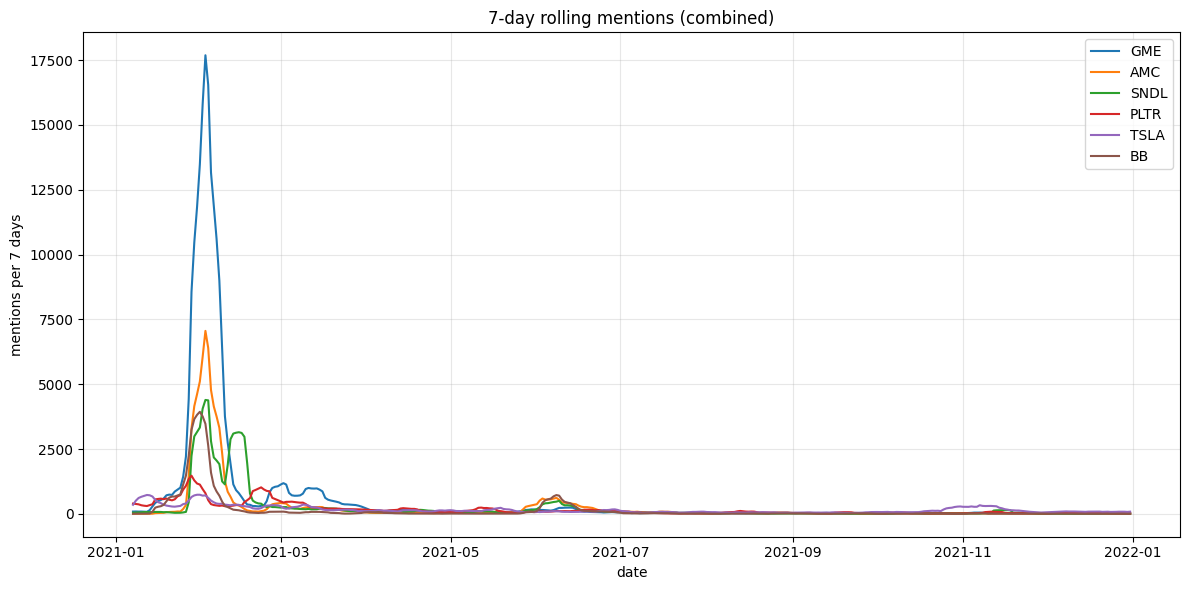

In [13]:
# PLOT 1 - weekly rolling mentions (much smoother than the daily plots)
plt.figure(figsize=(12, 6))
for ticker in chosen:
    if ticker in weekly.columns:
        plt.plot(weekly.index, weekly[ticker], linewidth=1.5, label=ticker)
plt.title(f'{ROLL_DAYS}-day rolling mentions (combined)')
plt.xlabel('date'); plt.ylabel(f'mentions per {ROLL_DAYS} days')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

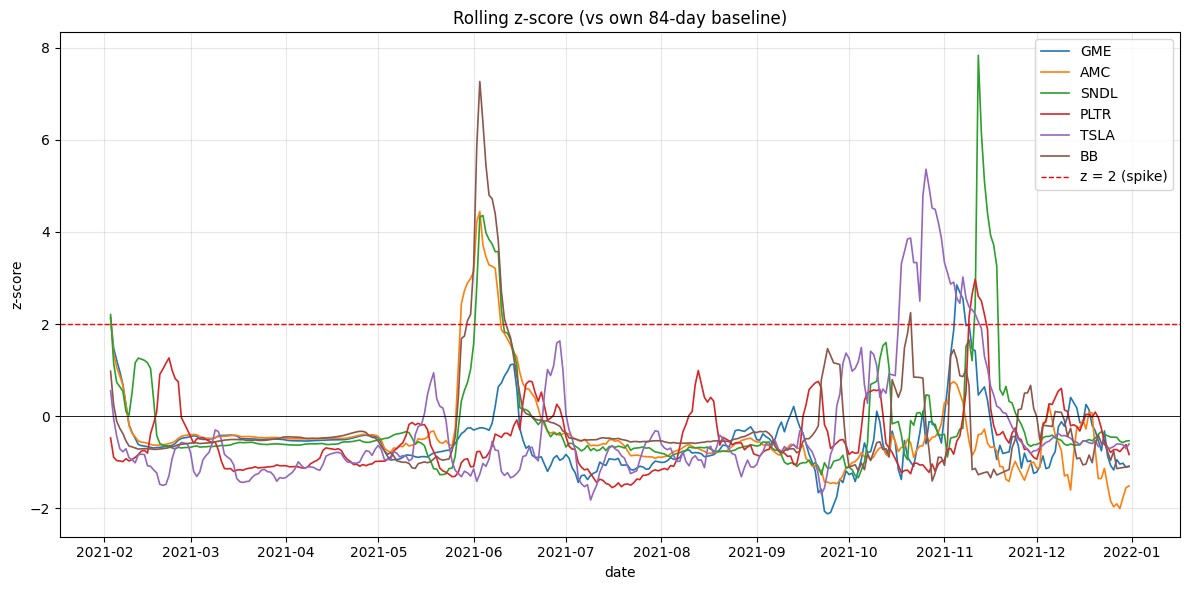

In [14]:
# PLOT 2 - rolling z-score: spike vs the ticker's OWN recent history.
# z > 2 (dashed line) = a real attention spike for that ticker.
plt.figure(figsize=(12, 6))
for ticker in chosen:
    if ticker in zscore.columns:
        plt.plot(zscore.index, zscore[ticker], linewidth=1.2, label=ticker)
plt.axhline(2, color='red', linestyle='--', linewidth=1, label='z = 2 (spike)')
plt.axhline(0, color='black', linewidth=0.6)
plt.title(f'Rolling z-score (vs own {Z_BASELINE}-day baseline)')
plt.xlabel('date'); plt.ylabel('z-score')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

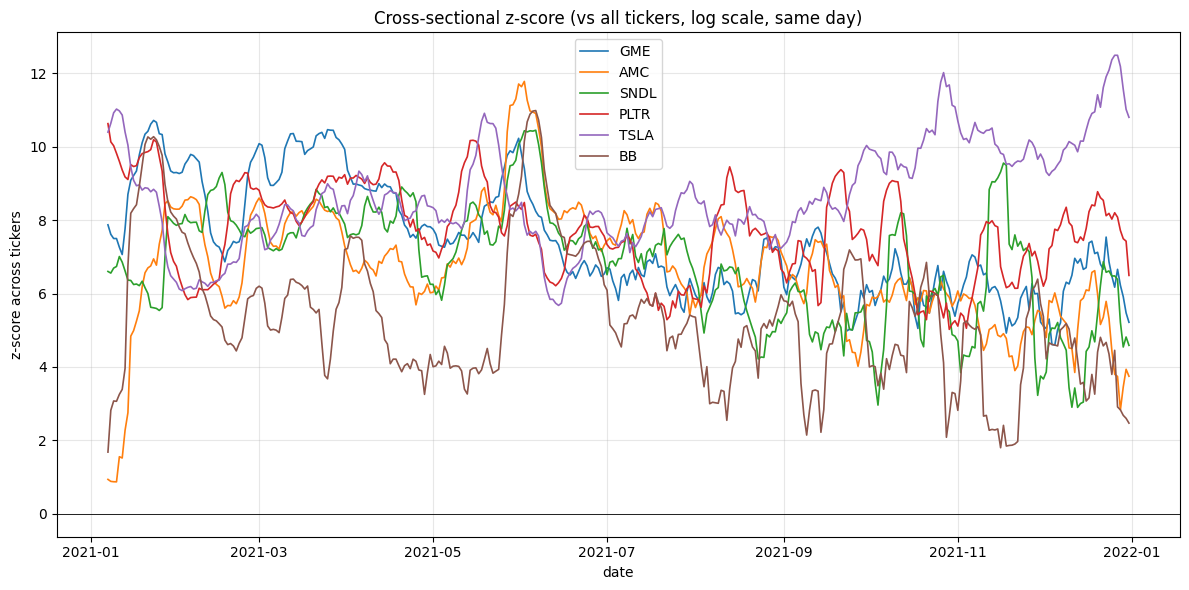

In [15]:
# PLOT 3 - cross-sectional z-score: the ticker vs ALL other tickers that day.
# High = dominating the conversation; rising = climbing the leaderboard.
plt.figure(figsize=(12, 6))
for ticker in chosen:
    if ticker in cs_z.columns:
        plt.plot(cs_z.index, cs_z[ticker], linewidth=1.2, label=ticker)
plt.axhline(0, color='black', linewidth=0.6)
plt.title('Cross-sectional z-score (vs all tickers, log scale, same day)')
plt.xlabel('date'); plt.ylabel('z-score across tickers')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Reddit vs X - who moves first?

The merged X (Twitter) data (several HuggingFace dumps - see `src/x_data.py`)
covers **2015-2020 and 2022-2024, with a hole across all of 2021** (just 71
stray tweets), and carries NO like counts - so this comparison uses RAW
mention counts only (one post/tweet = 1) on a window where BOTH sources
have data.

**If notebook 01's window misses the X data, this section builds its own.**
The default 2021 window sits exactly in the X hole, which used to make this
section silently produce nothing. Now, when the slice gives fewer than
`MIN_OVERLAP_DAYS` of two-source overlap, the cell below rebuilds per-source
counts straight from `posts.parquet` (all subreddits) over `FALLBACK_WINDOW`
(2022-2023 by default - both sources are dense there). The first build scans
~1.1M posts (a few minutes) and caches the counts under `data/processed/`, so
re-runs are instant. Notebook 01's window still rules everything ABOVE this
section.

For each ticker you get:

1. **A three-line plot** - Reddit, X, combined - as 7-day rolling totals,
   each divided by its own maximum so the SHAPES are comparable even though
   Reddit's volume is much larger. If one line's peak sits visibly to the
   left of the other's, that source moved first.
2. **A lead/lag estimate (cross-correlation).** We compute the correlation
   between the Reddit series today and the X series shifted by `k` days, for
   every `k` from -MAX_LAG to +MAX_LAG. The `k` with the highest correlation
   is the best alignment of the two curves:
   `k > 0` means X's moves happened `k` days BEFORE Reddit's (X leads);
   `k < 0` means Reddit leads. Correlation is scale-free, so the volume
   difference between the platforms doesn't matter.

Caveats: with a short overlap window the lag estimate is noisy - treat
+-1 day as 'simultaneous'; both series must actually move (a flat series
correlates with nothing); and this is attention lead/lag, not price lead/lag
(that is Stage 1 step 4, notebook 06).

slice window has only 0 day(s) of overlap (need 60) ->
building the comparison from posts.parquet over 2022-01-01 .. 2024-01-01
loaded cached counts: c:\Users\alexd\Desktop\GIC\RetailFlow1\data\processed\compare_by_source_2022-01-01_2024-01-01.parquet
overlap window: 2022-01-02 -> 2023-12-24
comparing: ['BBBY', 'BTC', 'TSLA', 'ETH', 'AAPL', 'SPY']


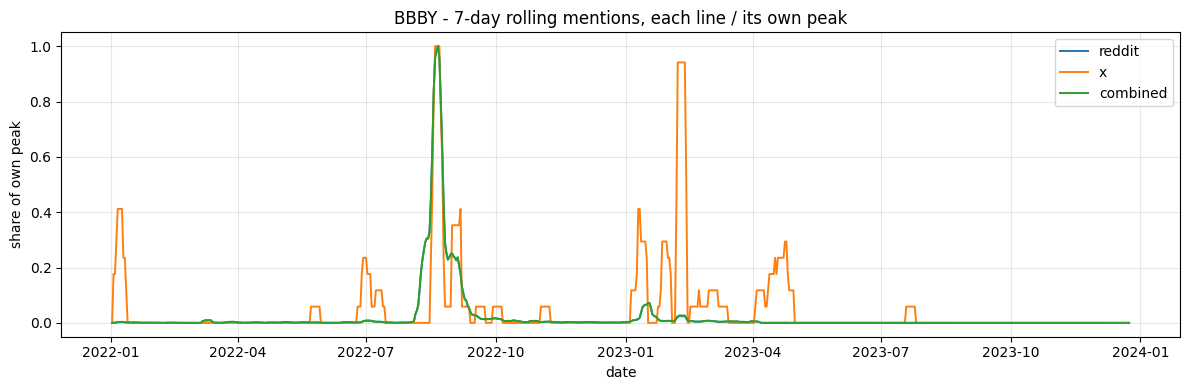

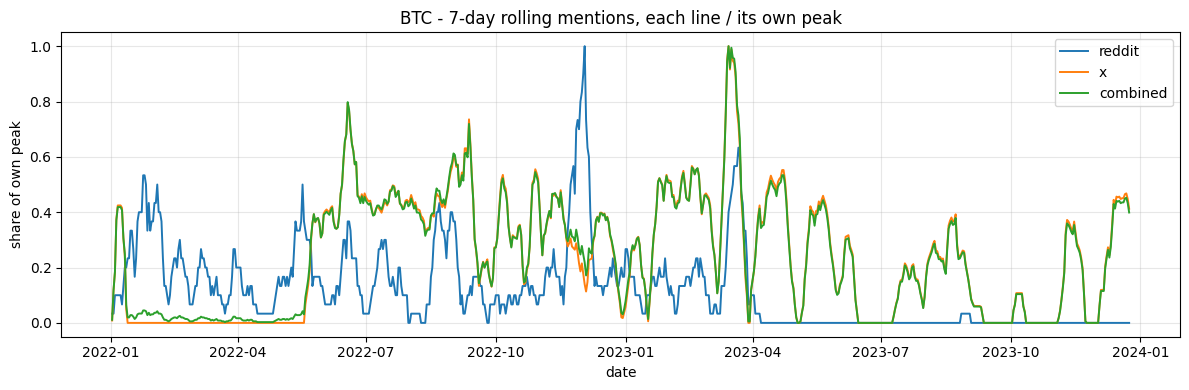

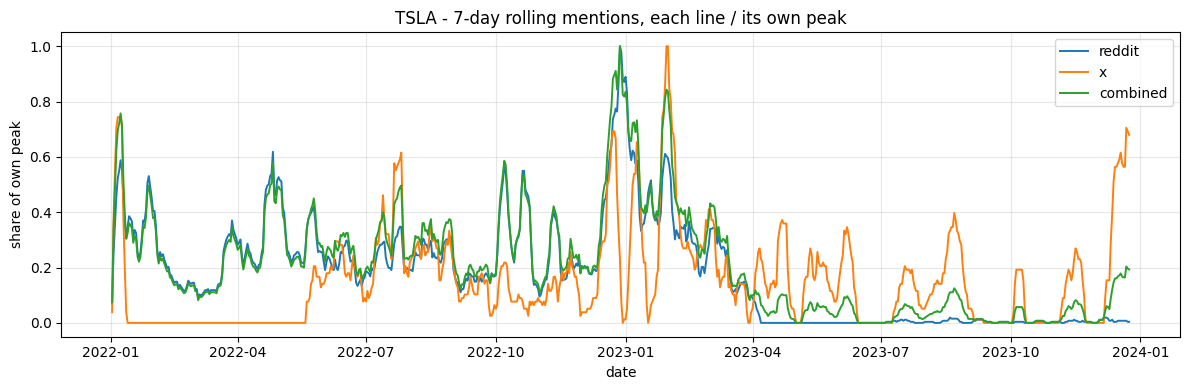

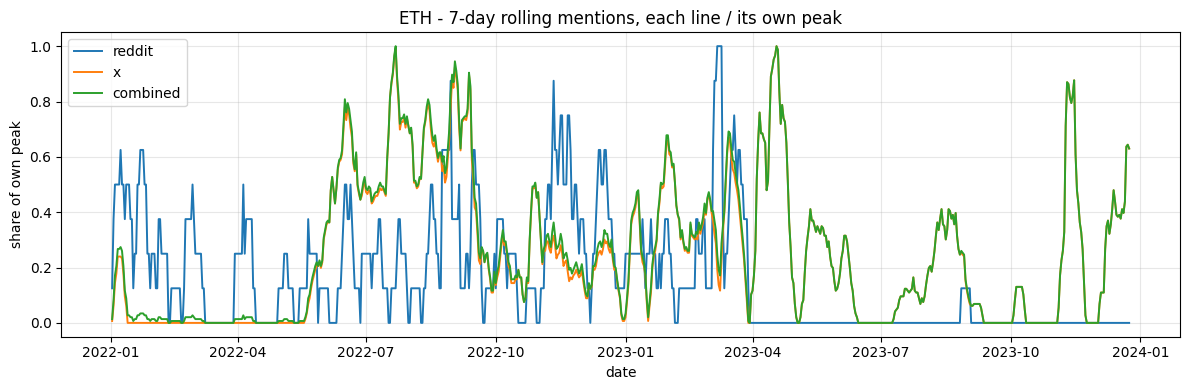

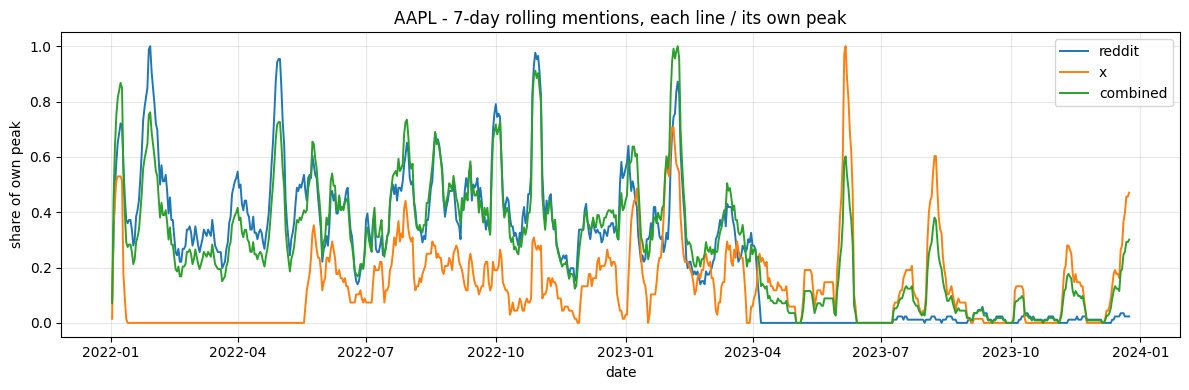

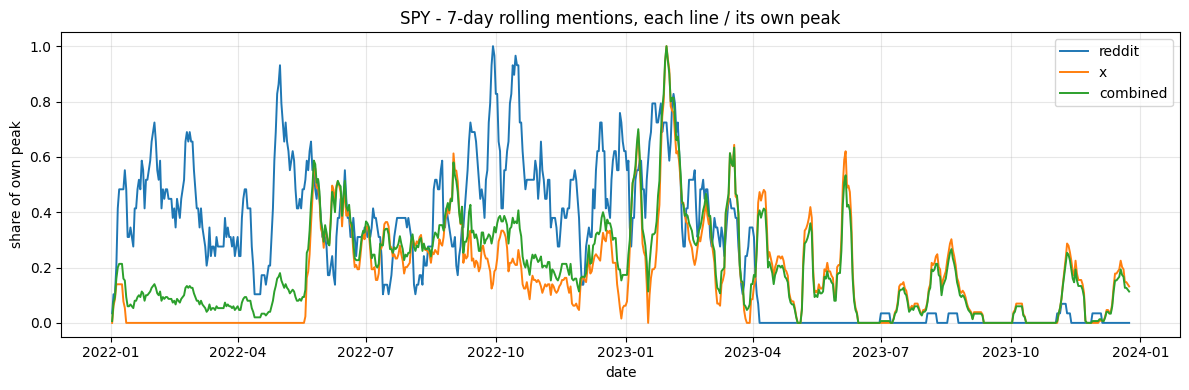

In [16]:
# ============ COMPARISON PARAMETERS ============
COMPARE_TICKERS  = []   # [] = top TOP_N tickers by combined mentions in the overlap
MAX_LAG          = 14   # days tested in each direction for the lead/lag
MIN_OVERLAP_DAYS = 60   # need at least this many days where BOTH sources were live
# Used only when notebook 01's window misses the X data (the X dumps have a
# hole across 2021): the comparison then builds its own counts straight from
# posts.parquet over this window instead of going silent. First build scans
# ~1.1M posts (a few minutes); the counts are cached, re-runs are instant.
FALLBACK_WINDOW  = ('2022-01-01', '2024-01-01')   # start inclusive, end EXCLUSIVE
# ===============================================

series = {}   # ticker -> (reddit_series, x_series); filled below, used by the lag cell

def overlap_span(frame):
    """(lo, hi) of the span where BOTH sources have data, else (None, None)."""
    if not {'reddit', 'x'} <= set(frame['source'].unique()):
        return None, None
    lo = max(frame.loc[frame['source'] == s, 'date'].min() for s in ('reddit', 'x'))
    hi = min(frame.loc[frame['source'] == s, 'date'].max() for s in ('reddit', 'x'))
    return lo, hi

bs = by_source.copy()
bs['date'] = pd.to_datetime(bs['date'])
lo, hi = overlap_span(bs)

if lo is None or (hi - lo).days < MIN_OVERLAP_DAYS:
    # Notebook 01's slice doesn't (usefully) overlap the X data - a handful
    # of stray tweets can make both sources LOOK present while the real
    # overlap is a day or two (the 2021 window: 71 tweets, all Dec 27).
    # Build the comparison from the FULL dataset over FALLBACK_WINDOW; the
    # slice window still rules everything above this section.
    f_lo, f_hi = FALLBACK_WINDOW
    got = 'no two-source overlap' if lo is None else f'only {(hi - lo).days} day(s) of overlap'
    print(f'slice window has {got} (need {MIN_OVERLAP_DAYS}) ->')
    print(f'building the comparison from posts.parquet over {f_lo} .. {f_hi}')
    cache = os.path.join(ROOT, 'data', 'processed',
                         f'compare_by_source_{f_lo}_{f_hi}'
                         + ('_cashtags' if CASHTAGS_ONLY else '') + '.parquet')
    if os.path.exists(cache):
        bs = pd.read_parquet(cache)
        print('loaded cached counts:', cache)
    else:
        full = pd.read_parquet(
            os.path.join(ROOT, 'data', 'processed', 'posts.parquet'),
            columns=['date', 'title', 'selftext', 'score', 'source'],
            filters=[('date', '>=', f_lo), ('date', '<', f_hi)])
        print('scanning', f'{len(full):,}', 'posts (first run only - cached after this)')
        parts = []
        for src_name in ('reddit', 'x'):
            d = build_daily_counts(full[full['source'] == src_name], universe,
                                   cashtags_only=CASHTAGS_ONLY)
            d['source'] = src_name
            parts.append(d)
        bs = pd.concat(parts, ignore_index=True)
        bs.to_parquet(cache, index=False)
        print('cached ->', cache)
    bs['date'] = pd.to_datetime(bs['date'])
    lo, hi = overlap_span(bs)

if lo is None:
    print('Only', sorted(set(bs['source'])), 'available - nothing to compare.')
    print('posts.parquet has no X rows: run data_ingestion/scripts/fetch_x_data.py')
    print('then add_x_data.py to merge them.')
else:
    bs = bs[(bs['date'] >= lo) & (bs['date'] <= hi)]
    print('overlap window:', lo.date(), '->', hi.date())

    if COMPARE_TICKERS:
        compare = COMPARE_TICKERS
    else:
        compare = list(bs.groupby('ticker')['mention_count'].sum()
                       .sort_values(ascending=False).head(TOP_N).index)
    print('comparing:', compare)

    def rolling_series(frame, ticker):
        """7-day rolling mention total for one ticker, missing days = 0."""
        one = frame[frame['ticker'] == ticker]
        if one.empty:
            return None
        s = (one.groupby('date')['mention_count'].sum()
             .reindex(pd.date_range(lo, hi, freq='D')).fillna(0))
        return s.rolling(7, min_periods=1).sum()

    for ticker in compare:
        r = rolling_series(bs[bs['source'] == 'reddit'], ticker)
        x = rolling_series(bs[bs['source'] == 'x'], ticker)
        if r is None or x is None:
            print('skip', ticker, '- no mentions in one of the sources')
            continue
        series[ticker] = (r, x)
        plt.figure(figsize=(12, 4))
        for s, label in ((r, 'reddit'), (x, 'x'), (r + x, 'combined')):
            peak = s.max()
            plt.plot(s.index, s / peak if peak > 0 else s, linewidth=1.4, label=label)
        plt.title(f'{ticker} - 7-day rolling mentions, each line / its own peak')
        plt.xlabel('date'); plt.ylabel('share of own peak')
        plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [17]:
# Lead/lag by cross-correlation. x.shift(k) moves X's values k days LATER,
# so corr(reddit[t], x[t-k]) being highest at k=+2 means: what X did two
# days ago best matches what Reddit does today -> X moved first (X leads).
def best_lead_lag(reddit_s, x_s, max_lag=14):
    """Returns (best_k, best_corr). k > 0 = X leads Reddit by k days."""
    best_k, best_c = None, None
    for k in range(-max_lag, max_lag + 1):
        c = reddit_s.corr(x_s.shift(k))
        if pd.notna(c) and (best_c is None or c > best_c):
            best_k, best_c = k, c
    return best_k, best_c

if not series:
    print('nothing to compare - see the cell above')
else:
    rows = []
    for ticker, (r, x) in series.items():
        active_days = int(((r + x) > 0).sum())
        if active_days < MIN_OVERLAP_DAYS:
            rows.append({'ticker': ticker, 'best_lag_days': None, 'corr': None,
                         'verdict': f'only {active_days} active days - too little data'})
            continue
        k, c = best_lead_lag(r, x, MAX_LAG)
        if k is None:
            verdict = 'no correlation (one series may be flat)'
        elif abs(k) <= 1:
            verdict = f'simultaneous (peak corr {c:.2f} at {k:+d}d)'
        elif k > 0:
            verdict = f'X LEADS Reddit by {k} days (corr {c:.2f})'
        else:
            verdict = f'Reddit LEADS X by {-k} days (corr {c:.2f})'
        rows.append({'ticker': ticker, 'best_lag_days': k,
                     'corr': None if c is None else round(c, 3), 'verdict': verdict})
    print(pd.DataFrame(rows).to_string(index=False))

ticker  best_lag_days  corr                              verdict
  BBBY              0 0.606 simultaneous (peak corr 0.61 at +0d)
   BTC              5 0.183 X LEADS Reddit by 5 days (corr 0.18)
  TSLA              1 0.302 simultaneous (peak corr 0.30 at +1d)
   ETH              5 0.211 X LEADS Reddit by 5 days (corr 0.21)
  AAPL              0 0.147 simultaneous (peak corr 0.15 at +0d)
   SPY             -9 0.303 Reddit LEADS X by 9 days (corr 0.30)
